Considerăm o urnă în care avem 3 bile roşii, 4 albastre şi 2 negre. Aruncăm un zar; dacă obţinem un număr prim,
adăugăm o bilă neagră în urnă, dacă obţinem 6, adăugăm o bilă roşie, iar în celelalte cazuri adăugăm o bilă albastră.
Apoi extragem o bilă din urnă.

a) Simulaţi în Python experimentul de mai sus.

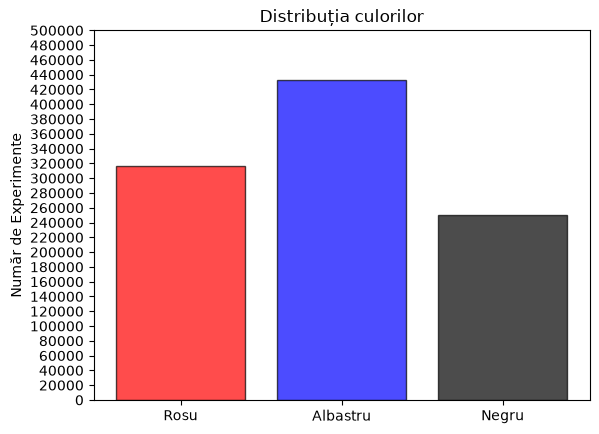

Results: [316806, 433165, 250029]


In [22]:
import numpy as np
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

np.random.seed(998244353)

def run():
    r = 3 # rosii
    a = 4 # albastre
    n = 2 # negre
    dice = np.random.randint(1,7)
    if dice in (2, 3, 5):
        n = n + 1
    elif dice == 6:
        r = r + 1
    else:
        a = a + 1

    choice = np.random.randint(0, n+r+a)
    if choice < r:
        return 0 # rosu
    elif choice < r+a:
        return 1 # albastru
    else:
        return 2 # negru

def runs(iter_cnt):
    results = [0,0,0]
    for i in range(iter_cnt):
        result = run()
        results[result] = results[result] + 1
    plt.bar(["Rosu", "Albastru", "Negru"], results, alpha=0.7, color=['red', 'blue', 'black'], edgecolor='black')
    plt.title('Distribuția culorilor')
    plt.yticks(np.arange(0,520000,20000))
    plt.xlabel('')
    plt.ylabel('Număr de Experimente')
    plt.show()

    print(f"Results: {results}")

runs(1000000)

b) Folosind modelarea făcută, estimaţi probabilitatea de a obţine o bilă roşie.

- Rosu: $31.6806\% \approx 31.7\%$

- Albastru: $43.3165\% \approx 43.3\%$

- Negru: $25.00029\% \approx 25\%$

c) Calculaţi probabilitatea teoretică a evenimentului de mai sus şi comparaţi-o cu cea obţinută.

Consideram evenimentele aleatoare:

- P - zarul este prim

- S (sase) - zarul este 6

- O (other) - zarul este altceva

- R - bila aleasa este rosie

$$P(R) = P(R|P) \cdot P(P) + P(R|S) \cdot P(S) + P(R|O) \cdot P(O) = (3/10 \cdot 1/2) + (4/10 \cdot 1/6) +  (3/10 \cdot 2/6) = $$
$$ = (3/10 \cdot 5/6) + (4/10 \cdot 1/6) = 3/10+1/60=19/60$$

$$19/60 = 0.31(6) = 31.(6)\%$$

Extra: 

A - bila aleasa este albastra

$$P(A) = P(A|P) \cdot P(P) + P(A|S) \cdot P(S) + P(A|O) \cdot P(O) = (4/10 \cdot 1/2) + (4/10 \cdot 1/6) +  (5/10 \cdot 2/6) = $$
$$ = (4/10 \cdot 4/6) + (5/10 \cdot 2/6) = 4/10+2/60=26/60$$

$$26/60 = 0.43(3) = 43.(3)\%$$

N - bila aleasa este neagra

$$P(N) = P(N|P) \cdot P(P) + P(N|S) \cdot P(S) + P(N|O) \cdot P(O) = (3/10 \cdot 1/2) + (2/10 \cdot 1/6) +  (2/10 \cdot 2/6) = $$
$$ = (3/10 \cdot 1/2) + (2/10 \cdot 1/2) = 1/4$$

$$1/4 = 0.25 = 25\%$$